In [11]:
#step 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual theme
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [12]:
#step 2
# Load dataset
file_path = "Unemployment in India.csv"
df = pd.read_csv(file_path)

# 1. Clean whitespace from column headers
df.columns = df.columns.str.strip()

# 2. Standardize column names for easy access
df.rename(columns={
    'Region': 'State',
    'Date': 'Date',
    'Frequency': 'Frequency',
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate',
    'Region.1': 'Region'
}, inplace=True, errors='ignore')

# 3. Drop rows with null values if present
df.dropna(inplace=True)

# 4. Parse Date column to datetime
df['Date'] = pd.to_datetime(df['Date'].str.strip(), dayfirst=True)
df['Month'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year

print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nCleaned Data Types:\n", df.dtypes)
df.head()

Dataset Shape: (740, 9)

Missing Values:
 State                        0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Area                         0
Month                        0
Year                         0
dtype: int64

Cleaned Data Types:
 State                                   str
Date                         datetime64[us]
Frequency                               str
Unemployment_Rate                   float64
Employed                            float64
Labour_Participation_Rate           float64
Area                                    str
Month                                   str
Year                                  int32
dtype: object


,State,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Month,Year
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May,2019
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June,2019
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July,2019
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,August,2019
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,September,2019


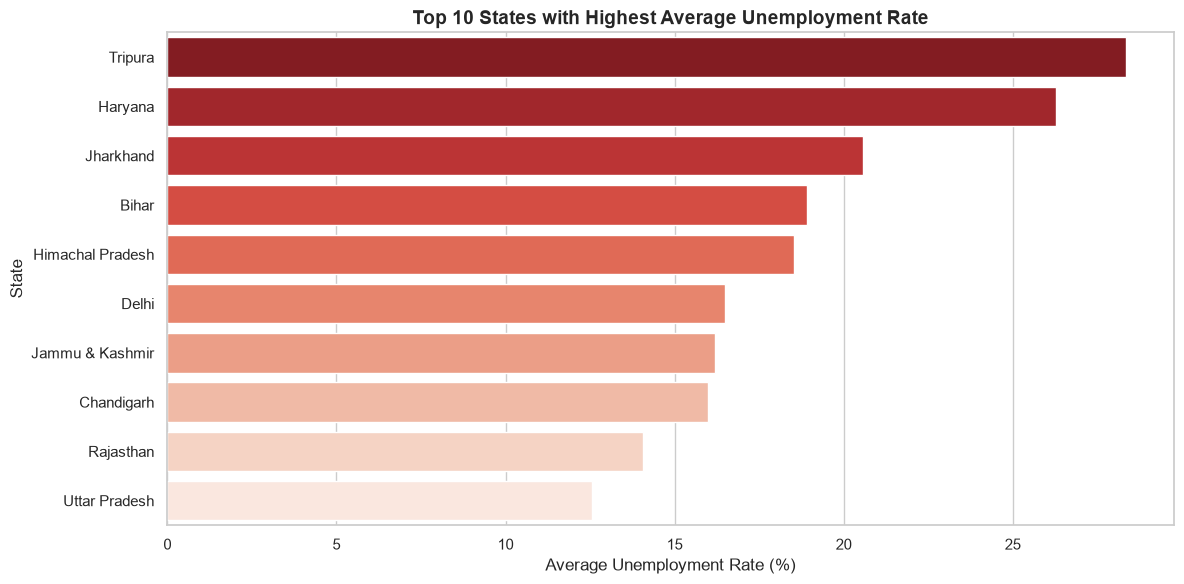

In [13]:
#step 3
# Compute mean rates per state
state_avg = df.groupby('State')['Unemployment_Rate'].mean().reset_index()
top_10_states = state_avg.sort_values(by='Unemployment_Rate', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_10_states,
    x='Unemployment_Rate',
    y='State',
    hue='State',
    legend=False,
    palette='Reds_r'
)
plt.title("Top 10 States with Highest Average Unemployment Rate", fontsize=14, weight='bold')
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

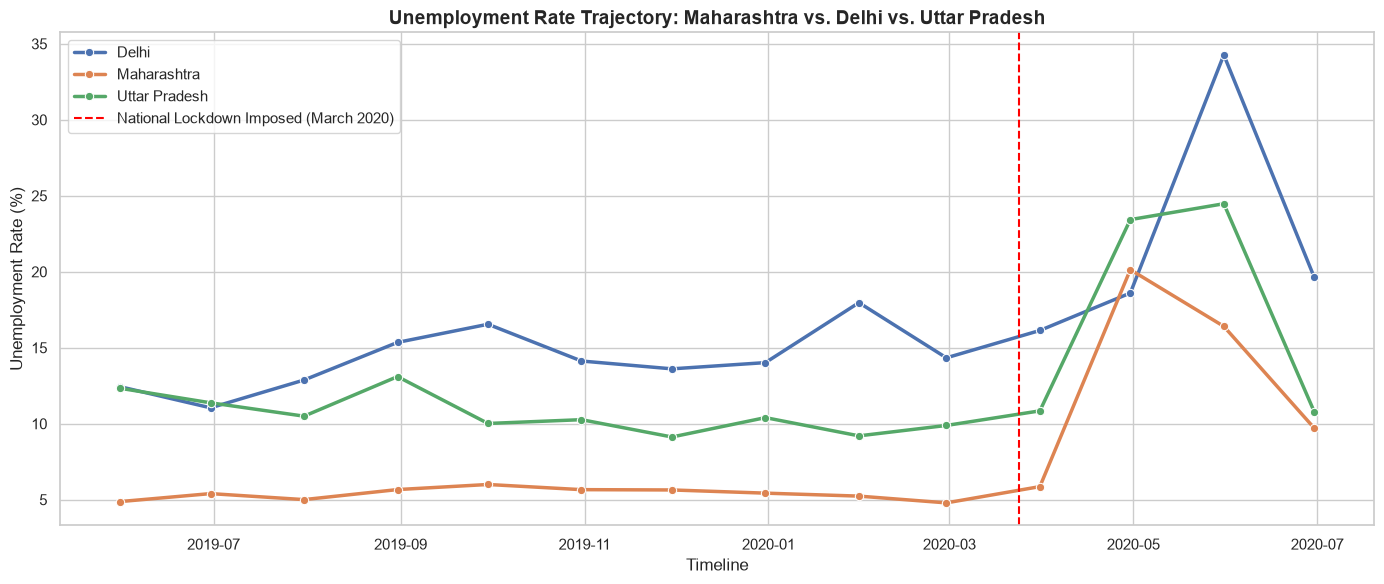

In [14]:
#step 4
selected_states = ['Maharashtra', 'Delhi', 'Uttar Pradesh']
df_selected = df[df['State'].isin(selected_states)].groupby(['Date', 'State'])['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=df_selected,
    x='Date',
    y='Unemployment_Rate',
    hue='State',
    marker='o',
    linewidth=2.5
)
plt.axvline(pd.to_datetime('2020-03-24'), color='red', linestyle='--', linewidth=1.5, label='National Lockdown Imposed (March 2020)')
plt.title("Unemployment Rate Trajectory: Maharashtra vs. Delhi vs. Uttar Pradesh", fontsize=14, weight='bold')
plt.xlabel("Timeline")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

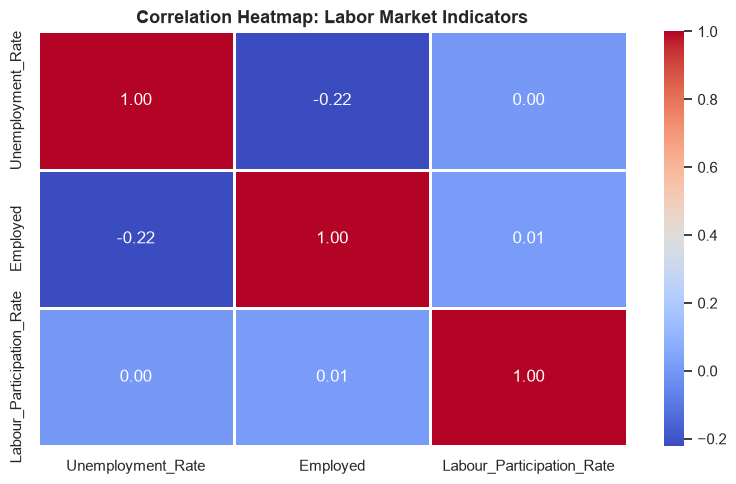

In [15]:
#step 5
plt.figure(figsize=(8, 5))
numeric_df = df[['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)
plt.title("Correlation Heatmap: Labor Market Indicators", fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

Pre-COVID vs. Post-COVID Metrics Summary:


Unemployment_Rate         \
                                           mean    std   
Period                                                   
Post-COVID (Apr 2020 Onwards)             20.19  16.18   
Pre-COVID (Before Apr 2020)                9.61   7.37   

                              Labour_Participation_Rate        
                                                   mean   std  
Period                                                         
Post-COVID (Apr 2020 Onwards)                     38.05  8.13  
Pre-COVID (Before Apr 2020)                       43.82  7.68

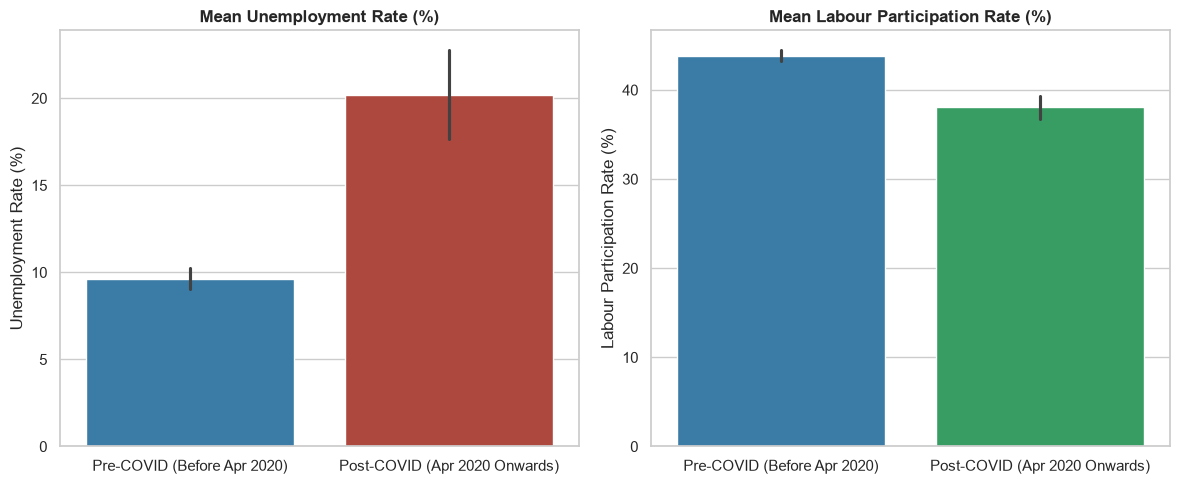

In [16]:
#step 6
# Period segment assignment
df['Period'] = np.where(df['Date'] < '2020-04-01', 'Pre-COVID (Before Apr 2020)', 'Post-COVID (Apr 2020 Onwards)')

# Grouped statistics
period_summary = df.groupby('Period')[['Unemployment_Rate', 'Labour_Participation_Rate']].agg(['mean', 'std']).round(2)
print("Pre-COVID vs. Post-COVID Metrics Summary:")
display(period_summary)

# Visual comparison bar plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    data=df, x='Period', y='Unemployment_Rate', 
    ax=axes[0], palette=['#2980b9', '#c0392b'], hue='Period', legend=False
)
axes[0].set_title("Mean Unemployment Rate (%)", weight='bold')
axes[0].set_ylabel("Unemployment Rate (%)")
axes[0].set_xlabel("")

sns.barplot(
    data=df, x='Period', y='Labour_Participation_Rate', 
    ax=axes[1], palette=['#2980b9', '#27ae60'], hue='Period', legend=False
)
axes[1].set_title("Mean Labour Participation Rate (%)", weight='bold')
axes[1].set_ylabel("Labour Participation Rate (%)")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()